# Figure 3 New

This notebook regenerates Figure 3 using the squared-decay quantity $G_\mu$ rather than the mean-fitness decay $F_\mu$. For each single-genotype starting point, diffusion replicates are averaged first to estimate $F_\mu$ for that start. Figure-level decay curves are then computed as $G_\mu = \mathbb{E}_{\nu}[F_\mu^2]$ by squaring those start-level curves and averaging over starting genotypes.


## Setup

Load the reusable simulation functions from `slide/`, configure the output folders, and define small notebook-local plotting and G_mu processing helpers. The helper functions here keep the notebook explicit while avoiding repeated indexing code.


In [12]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm

from slide.data_generation import nk_grid_pairs
from slide.data_processing import nk_metric_comparison_from_accuracy
from slide.direvo_functions import (
    build_NK_landscape_function,
    build_mutation_function,
    get_single_decay_rate,
    model_function,
    run_diffusion,
)
from slide.utils import get_figures_dir, get_processed_data_dir, get_raw_data_dir, load_pickle, save_pickle

OVERWRITE_PKL: bool = True
SAVE_FIGURES: bool = True
SAVE_TYPE_LIST = ("pdf", "png", "eps")
PANEL_DPI = 350

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
for figure_type in SAVE_TYPE_LIST:
    (FIGURES_DIR / figure_type).mkdir(parents=True, exist_ok=True)

print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")


def save_panel_figure(fig: plt.Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a panel figure in each configured output format."""
    if not SAVE_FIGURES:
        return
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"{stem}.{figure_type}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: plt.Axes, letter: str) -> None:
    """Add the panel letter annotation used in the paper figures."""
    ax.text(-0.16, 1.08, letter, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top", ha="left")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/lady5906/workspace_python/SLIDE/raw_data
processed_data: /home/lady5906/workspace_python/SLIDE/processed_data
figures: /home/lady5906/workspace_python/SLIDE/figures


## Files And Shared Helpers

The new notebook writes separate Figure-3-new payloads. Raw arrays store start-level $F_\mu$ trajectories after averaging over replicate diffusion experiments; processing cells convert those arrays to $G_\mu$ by squaring before averaging over starts.


In [13]:
RAW_FILES = {
    "nk_decay_grid": "figure3_new_nk_decay_grid_raw.pkl",
    "nk_popsize_accuracy": "figure3_new_nk_popsize_accuracy_raw.pkl",
    "nk_mutation_accuracy": "figure3_new_nk_mutation_accuracy_raw.pkl",
}

PROCESSED_FILES = {
    "decay_examples": "figure3_new_decay_examples_processed.pkl",
    "ruggedness_accuracy": "figure3_new_ruggedness_accuracy_processed.pkl",
    "popsize_accuracy": "figure3_new_popsize_accuracy_processed.pkl",
    "mutation_accuracy": "figure3_new_mutation_accuracy_processed.pkl",
    "metric_comparison": "figure3_new_metric_comparison_processed.pkl",
}


def ordered_unique_pairs(pairs: list[tuple[int, int]]) -> list[tuple[int, int]]:
    """Deduplicate NK pairs while preserving the order returned by `nk_grid_pairs`."""
    return list(dict.fromkeys((int(N), int(K)) for N, K in pairs))


def random_start(rng_key: jr.PRNGKey, *, n_sites: int, num_alleles: int) -> np.ndarray:
    """Sample one single-genotype starting point as an integer coordinate array."""
    return np.asarray(jr.randint(rng_key, (n_sites,), 0, num_alleles), dtype=np.int32)


def repeated_population(start: np.ndarray, popsize: int) -> jnp.ndarray:
    """Create a clonal JAX population from one single-genotype starting point."""
    start_array = jnp.asarray(start, dtype=jnp.int32)
    return jnp.tile(start_array[None, :], (int(popsize), 1))


FITNESS_ONLY_HISTORY = {"fitness": lambda *args, **kwargs: kwargs["fitnesses"]}


def run_nk_start_averaged_diffusion(
    *,
    rng_key: jax.Array,
    n_sites: int,
    k: int,
    num_alleles: int,
    starts: np.ndarray,
    popsize: int,
    mutation_rate_per_site: float,
    num_reps_per_start: int,
    num_steps: int,
) -> np.ndarray:
    """Run start-resolved diffusion on one NK landscape with JAX batching.

    The NK landscape is built exactly once from `rng_key`. All starting genotypes
    and all replicate diffusion experiments are then evaluated with nested `jax.vmap`
    calls on that same landscape. The returned array has shape `(num_starts, num_steps)`: every row is
    the start-level `F_mu` trajectory after averaging over population cells and then
    over `num_reps_per_start` replicate diffusion experiments. Only fitness history
    is recorded to avoid materialising the full population history.
    """
    starts_array = jnp.asarray(starts, dtype=jnp.int32)
    num_starts = int(starts_array.shape[0])
    fitness_function = build_NK_landscape_function(rng_key, n_sites, k)
    mutation_function = build_mutation_function(mutation_rate_per_site, num_alleles)
    initial_populations = jnp.repeat(starts_array[:, None, :], int(popsize), axis=1)
    replicate_keys = jr.split(
        jr.fold_in(rng_key, 10_000),
        num_starts * int(num_reps_per_start),
    ).reshape(num_starts, int(num_reps_per_start), 2)

    def run_one_replicate(initial_population: jax.Array, replicate_key: jax.Array) -> jax.Array:
        history = run_diffusion(
            replicate_key,
            initial_population,
            mutation_function,
            fitness_function=fitness_function,
            num_steps=num_steps,
            extra_function_dict=FITNESS_ONLY_HISTORY,
        )[1]
        return history["fitness"].mean(axis=-1)

    run_one_start = jax.vmap(run_one_replicate, in_axes=(None, 0))
    run_all_starts = jax.jit(jax.vmap(run_one_start, in_axes=(0, 0)))
    replicate_curves = run_all_starts(initial_populations, replicate_keys)
    return np.asarray(replicate_curves.mean(axis=1), dtype=float)


def start_curves_to_gmu(start_curves: np.ndarray, *, average_axis: int | tuple[int, ...] = -2) -> np.ndarray:
    """Convert start-level `F_mu` curves to `G_mu` by squaring before averaging starts."""
    return np.square(np.asarray(start_curves, dtype=float)).mean(axis=average_axis)


def normalize_curve(curve: np.ndarray) -> np.ndarray:
    """Normalize one decay curve by its initial value for fitting and plotting."""
    curve = np.asarray(curve, dtype=float)
    return curve / curve[0]


def fit_gmu_decay(g_mu: np.ndarray, *, mutation_rate: float, num_steps: int) -> tuple[float, float]:
    """Fit the squared-decay model and return `(rho_2_fit, fitted_constant)`.

    Since `G_mu` follows `exp(-2 * mu * rho_2)`, the existing single-exponential fitter
    is called with `mut=2 * mutation_rate`. The returned rate is therefore directly on
    the `rho_2` scale used in the paper.
    """
    normalized = normalize_curve(g_mu)
    return get_single_decay_rate(normalized, mut=2 * mutation_rate, num_steps=num_steps)


def fitted_gmu_curve(g_mu: np.ndarray, *, mutation_rate: float) -> tuple[np.ndarray, float]:
    """Return the fitted normalized `G_mu` curve and fitted `rho_2` value."""
    x = np.arange(len(g_mu))
    rho_2_fit, constant = fit_gmu_decay(g_mu, mutation_rate=mutation_rate, num_steps=len(g_mu))
    fitted = model_function(x, rho_2_fit, constant, mut=2 * mutation_rate)
    return fitted, float(rho_2_fit)


def print_params(title: str, params: dict, path: Path) -> None:
    """Print a compact parameter block before long-running generation cells."""
    print(f"\n---\n{title}:")
    for key, value in params.items():
        print(f"  {key}: {value}")
    print(f"Save path: {path}")
    print("---\n")


## NK Decay Grid - Panels A, B, And E

Generate the start-resolved NK diffusion grid. For each landscape and starting genotype, the notebook stores a replicate-averaged $F_\mu$ trajectory. Panels A, B, and E immediately convert these trajectories to $G_\mu$ by squaring first and then averaging over starts.


In [ ]:
grid_params = {
    "N_range": (10, 50),
    "num_grid_samples": 10,
    "A": 2,
    "mutation_rate": 0.5,
    "popsize": 2500,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
}
raw_pairs = nk_grid_pairs(grid_params["N_range"], grid_params["num_grid_samples"], K_start=0)
grid_params["nk_pairs"] = ordered_unique_pairs(raw_pairs)

nk_decay_grid_path = RAW_DATA_DIR / RAW_FILES["nk_decay_grid"]
print_params("Figure 3 new NK G_mu grid parameters", grid_params, nk_decay_grid_path)

if nk_decay_grid_path.exists() and not OVERWRITE_PKL:
    print(f"{nk_decay_grid_path} already exists. Loading existing raw payload.")
    nk_decay_grid_payload = load_pickle(nk_decay_grid_path)
else:
    pair_keys = jr.split(jr.PRNGKey(grid_params["seed"]), len(grid_params["nk_pairs"]))
    nk_decay_grid = []

    for pair_key, (N, K) in tqdm(list(zip(pair_keys, grid_params["nk_pairs"])), desc="Figure 3 new NK G_mu grid"):
        landscape_keys = jr.split(pair_key, grid_params["num_landscapes"])
        pair_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 100_000 + landscape_index), grid_params["num_starts"])
            starts = np.asarray([
                random_start(start_key, n_sites=N, num_alleles=grid_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=N,
                k=K,
                num_alleles=grid_params["A"],
                starts=starts,
                popsize=grid_params["popsize"],
                mutation_rate_per_site=grid_params["mutation_rate"] / N,
                num_reps_per_start=grid_params["num_reps_per_start"],
                num_steps=grid_params["M"],
            )
            pair_results.append(start_curves)
        nk_decay_grid.append(np.asarray(pair_results))

    nk_decay_grid_payload = {
        "data": np.asarray(nk_decay_grid),
        "params": grid_params,
        "metadata": {
            "description": "Start-resolved NK diffusion grid for Figure 3 new G_mu panels A, B, and E.",
            "paper_reference": "Figure 3A-B/E",
            "output_key": "figure3_new_nk_decay_grid",
            "filename": RAW_FILES["nk_decay_grid"],
            "shape": "nk_pair, landscape, start, generation",
        },
    }
    save_pickle(nk_decay_grid_payload, nk_decay_grid_path)

nk_decay_grid = np.asarray(nk_decay_grid_payload["data"], dtype=float)
nk_decay_params = nk_decay_grid_payload["params"]
nk_pairs = np.asarray(nk_decay_params["nk_pairs"], dtype=int)
print(f"Loaded NK decay grid shape: {nk_decay_grid.shape}")



---
Figure 3 new NK G_mu grid parameters:
  N_range: (10, 50)
  num_grid_samples: 10
  A: 2
  mutation_rate: 0.5
  popsize: 2500
  num_landscapes: 25
  num_starts: 10
  num_reps_per_start: 3
  M: 25
  seed: 42
  start_policy: random
  nk_pairs: [(50, 49), (50, 43), (50, 38), (50, 32), (50, 27), (50, 21), (50, 16), (50, 10), (50, 5), (50, 0), (45, 44), (45, 39), (45, 34), (45, 29), (45, 24), (45, 19), (45, 14), (45, 9), (45, 4), (45, 0), (41, 40), (41, 35), (41, 31), (41, 26), (41, 22), (41, 17), (41, 13), (41, 8), (41, 4), (41, 0), (36, 35), (36, 31), (36, 27), (36, 23), (36, 19), (36, 15), (36, 11), (36, 7), (36, 3), (36, 0), (32, 31), (32, 27), (32, 24), (32, 20), (32, 17), (32, 13), (32, 10), (32, 6), (32, 3), (32, 0), (27, 26), (27, 23), (27, 20), (27, 17), (27, 14), (27, 11), (27, 8), (27, 5), (27, 2), (27, 0), (23, 22), (23, 19), (23, 17), (23, 14), (23, 12), (23, 9), (23, 7), (23, 4), (23, 2), (23, 0), (18, 17), (18, 15), (18, 13), (18, 11), (18, 9), (18, 7), (18, 5), (18, 3), 

Figure 3 new NK G_mu grid:   0%|          | 0/100 [00:00<?, ?it/s]

Loaded NK decay grid shape: (100, 25, 10, 25)


### Panel A - Example G_mu Decay Curves

Select two explicit NK pairs and plot their normalized $G_\mu$ curves. Within each selected landscape, replicate trajectories are averaged per starting genotype, then squared and averaged over starts.


Figure 3 new Panel A selected NK examples:
  smooth: grid_index=7, landscape=0, N=50, K=10, rho_NK=0.220, rho_2_fit=0.206
  rugged: grid_index=1, landscape=0, N=50, K=43, rho_NK=0.880, rho_2_fit=0.884


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


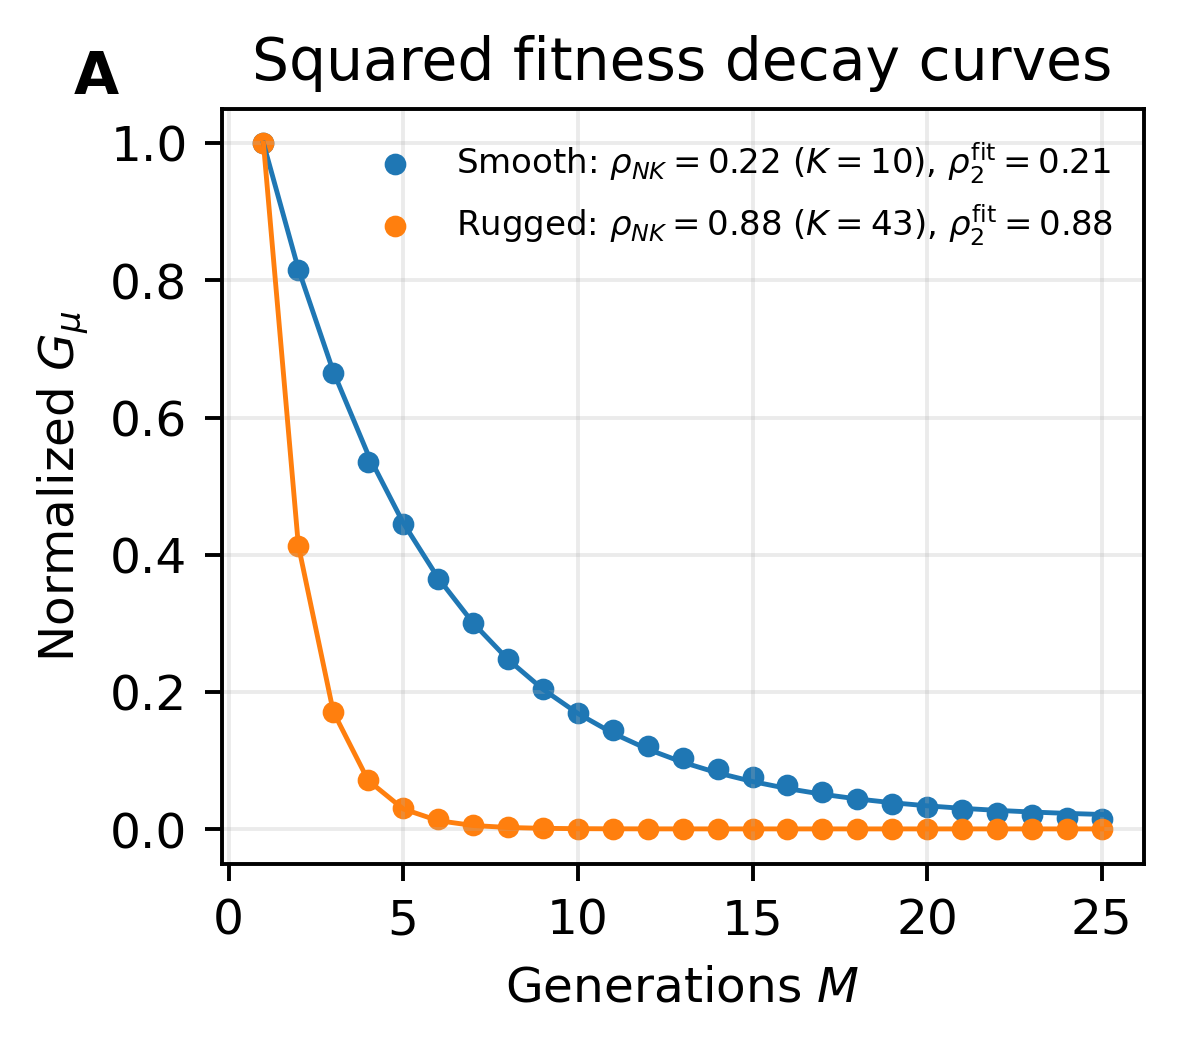

In [27]:
PANEL_A_NK_EXAMPLES: dict[str, tuple[int, int]] = {
    "smooth": (50, 10),
    "rugged": (50, 43),
}
PANEL_A_LANDSCAPE_INDEX = 0

pair_to_index = {(int(N), int(K)): index for index, (N, K) in enumerate(nk_pairs)}
decay_examples = {
    "smooth_rugged": [],
    "fitted_lines": [],
    "labels": [],
    "examples": {},
    "generations": np.arange(1, int(nk_decay_params["M"]) + 1),
}

for name, pair in PANEL_A_NK_EXAMPLES.items():
    if pair not in pair_to_index:
        raise ValueError(f"Requested Panel A pair {pair} is absent from nk_pairs: {nk_pairs.tolist()}")
    grid_index = pair_to_index[pair]
    N, K = pair
    rho_nk = (K + 1) / N
    start_curves = nk_decay_grid[grid_index, PANEL_A_LANDSCAPE_INDEX]
    g_mu = start_curves_to_gmu(start_curves, average_axis=0)
    normalized_g_mu = normalize_curve(g_mu)
    fitted_curve, rho_2_fit = fitted_gmu_curve(g_mu, mutation_rate=float(nk_decay_params["mutation_rate"]))
    label = rf"{name.title()}: $\rho_{{NK}}={rho_nk:.2f}$ ($K={K}$), $\rho_2^{{\mathrm{{fit}}}}={rho_2_fit:.2f}$"

    decay_examples["smooth_rugged"].append(normalized_g_mu)
    decay_examples["fitted_lines"].append(fitted_curve)
    decay_examples["labels"].append(label)
    decay_examples["examples"][name] = {
        "N": int(N),
        "K": int(K),
        "rho_NK": float(rho_nk),
        "rho_2_fit": float(rho_2_fit),
        "grid_index": int(grid_index),
        "landscape_index": int(PANEL_A_LANDSCAPE_INDEX),
        "num_starts": int(nk_decay_params["num_starts"]),
        "num_reps_per_start": int(nk_decay_params["num_reps_per_start"]),
        "legend_label": label,
    }

print("Figure 3 new Panel A selected NK examples:")
for name, info in decay_examples["examples"].items():
    print(
        f"  {name}: grid_index={info['grid_index']}, landscape={info['landscape_index']}, "
        f"N={info['N']}, K={info['K']}, rho_NK={info['rho_NK']:.3f}, "
        f"rho_2_fit={info['rho_2_fit']:.3f}"
    )

decay_examples_payload = {
    "data": decay_examples,
    "params": {**nk_decay_params, "panel_a_examples": decay_examples["examples"]},
    "metadata": {
        "description": "Processed NK G_mu example decay curves for Figure 3 new Panel A.",
        "paper_reference": "Figure 3A",
        "output_key": "figure3_new_decay_examples",
        "filename": PROCESSED_FILES["decay_examples"],
    },
}
save_pickle(decay_examples_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["decay_examples"])

fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
for curve, fitted_line, label, colour in zip(
    decay_examples["smooth_rugged"],
    decay_examples["fitted_lines"],
    decay_examples["labels"],
    ["tab:blue", "tab:orange"],
):
    ax.scatter(decay_examples["generations"], curve, label=label, color=colour, s=12)
    ax.plot(decay_examples["generations"], fitted_line, color=colour, linewidth=1)
ax.set_title(r"Squared fitness decay curves")
ax.set_xlabel(r"Generations $M$")
ax.set_ylabel(r"Normalized $G_\mu$")
ax.legend(frameon=False, fontsize=7)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "A")
save_panel_figure(fig, "figure_3_new_A")
plt.show()


### Panel B - G_mu Ruggedness Accuracy

For each NK landscape, average $F_\mu$ over replicate runs per start, square those start-level curves, and average over starts to obtain one $G_\mu$ curve per landscape. The panel reports fitted $\rho_2$ values across landscapes for each analytical $\rho_{NK}$.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


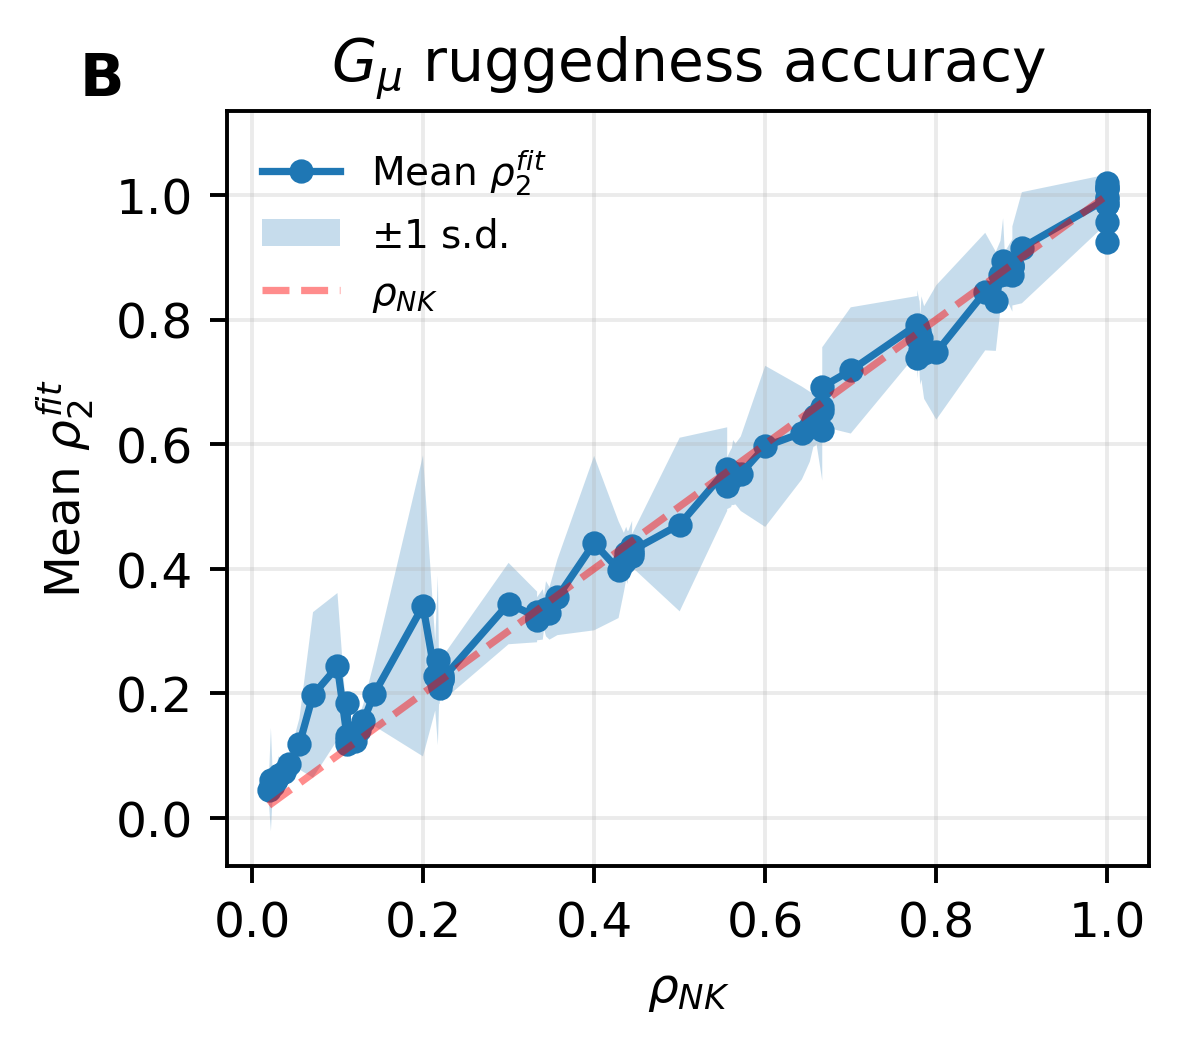

In [28]:
steps = int(nk_decay_params["M"])
mutation_rate = float(nk_decay_params["mutation_rate"])
rho_NK_all = (nk_pairs[:, 1] + 1) / nk_pairs[:, 0]
if np.any(rho_NK_all > 1):
    raise ValueError("Calculated rho_NK values must be in the range [0, 1]. Check NK pairs.")

rho_2_fit_by_pair = np.zeros((nk_decay_grid.shape[0], nk_decay_grid.shape[1]), dtype=float)
for pair_index in range(nk_decay_grid.shape[0]):
    for landscape_index in range(nk_decay_grid.shape[1]):
        g_mu = start_curves_to_gmu(nk_decay_grid[pair_index, landscape_index], average_axis=0)
        rho_2_fit_by_pair[pair_index, landscape_index] = fit_gmu_decay(
            g_mu,
            mutation_rate=mutation_rate,
            num_steps=steps,
        )[0]

order = np.argsort(rho_NK_all)
ruggedness_accuracy_processed = {
    "rho_NK": rho_NK_all[order],
    "rho_2_fit_mean": rho_2_fit_by_pair[order].mean(axis=1),
    "rho_2_fit_std": rho_2_fit_by_pair[order].std(axis=1),
    "rho_2_fit_all": rho_2_fit_by_pair,
    "rho_NK_all": rho_NK_all,
}

ruggedness_accuracy_payload = {
    "data": ruggedness_accuracy_processed,
    "params": nk_decay_params,
    "metadata": {
        "description": "Processed NK G_mu ruggedness prediction accuracy for Figure 3 new Panel B.",
        "paper_reference": "Figure 3B",
        "output_key": "figure3_new_ruggedness_accuracy",
        "filename": PROCESSED_FILES["ruggedness_accuracy"],
    },
}
save_pickle(ruggedness_accuracy_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["ruggedness_accuracy"])

panel_data = ruggedness_accuracy_processed
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(panel_data["rho_NK"], panel_data["rho_2_fit_mean"], "o-", markersize=4, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(
    panel_data["rho_NK"],
    panel_data["rho_2_fit_mean"] - panel_data["rho_2_fit_std"],
    panel_data["rho_2_fit_mean"] + panel_data["rho_2_fit_std"],
    alpha=0.25,
    label=r"$\pm$1 s.d.",
)
ax.plot(panel_data["rho_NK"], panel_data["rho_NK"], color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(r"$G_\mu$ ruggedness accuracy")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel(r"Mean $\rho_2^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")
save_panel_figure(fig, "figure_3_new_B")
plt.show()


### Panel E - Metric Comparison

Use the $G_\mu$-based fitted $\rho_2$ values from Panel B as the decay-rate metric in the normalized comparison against other ruggedness summaries.


In [ ]:
metric_comparison = nk_metric_comparison_from_accuracy(rho_NK_all, rho_2_fit_by_pair)
metric_comparison_processed = {
    "roughness_to_slope": metric_comparison[0],
    "fourier": metric_comparison[1],
    "rho_2_fit": metric_comparison[2],
    "paths_to_max": metric_comparison[3],
    "closest_max": metric_comparison[4],
    "rho_NK": metric_comparison[5],
    "local_epistasis": metric_comparison[6],
}
metric_comparison_payload = {
    "data": metric_comparison_processed,
    "params": nk_decay_params,
    "metadata": {
        "description": "Metric comparison using NK G_mu fitted rho_2 values for Figure 3 new Panel E.",
        "paper_reference": "Figure 3E",
        "output_key": "figure3_new_metric_comparison",
        "filename": PROCESSED_FILES["metric_comparison"],
    },
}
save_pickle(metric_comparison_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["metric_comparison"])

panel_data = metric_comparison_processed
fig, ax = plt.subplots(figsize=(6.8, 2.9), dpi=PANEL_DPI)
rho_axis = panel_data["rho_NK"]
rho_curve = np.asarray(panel_data["rho_2_fit"])
ax.plot(rho_axis, rho_curve / rho_curve.max(), label=r"$\rho_2^{fit}$", linewidth=1.5)
ax.plot(rho_axis, 1 - panel_data["fourier"] / panel_data["fourier"].max(), label=r"1 - Landscape $R^2$", alpha=0.75, linestyle="--")
ax.plot(rho_axis, panel_data["roughness_to_slope"] / panel_data["roughness_to_slope"].max(), label="Roughness-to-slope ratio", alpha=0.75, linestyle="--")
ax.plot(rho_axis, 1 - panel_data["paths_to_max"] / panel_data["paths_to_max"].max(), label="1 - Paths to maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, panel_data["closest_max"] / panel_data["closest_max"].max(), label="Distance to closest local maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, panel_data["local_epistasis"] / panel_data["local_epistasis"].max(), label="Local epistasis", alpha=0.75, linestyle="--")
ax.set_title("Ruggedness metric comparison")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel("Normalized ruggedness measurements")
ax.legend(loc="lower right", fontsize=7, frameon=False, ncol=2)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "E")
save_panel_figure(fig, "figure_3_new_E")
plt.show()


## Population-Size Accuracy Sweep - Panel C

Generate the population-size sensitivity data with start-resolved $F_\mu$ curves. The processed panel converts each landscape to $G_\mu$ by squaring start-level curves before averaging starts.


In [ ]:
popsize_params = {
    "N": 25,
    "K": 15,
    "A": 2,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "pop_sizes": np.logspace(start=1, stop=5, num=10, endpoint=True, dtype=int),
    "mutation_rate": 0.5,
}
popsize_params["rho_NK"] = (popsize_params["K"] + 1) / popsize_params["N"]

popsize_accuracy_path = RAW_DATA_DIR / RAW_FILES["nk_popsize_accuracy"]
print_params("Figure 3 new NK popsize G_mu parameters", popsize_params, popsize_accuracy_path)

if popsize_accuracy_path.exists() and not OVERWRITE_PKL:
    print(f"{popsize_accuracy_path} already exists. Loading existing raw payload.")
    popsize_accuracy_payload = load_pickle(popsize_accuracy_path)
else:
    popsize_key = jr.PRNGKey(popsize_params["seed"])
    landscape_keys = jr.split(popsize_key, popsize_params["num_landscapes"])
    popsize_accuracy = []

    for popsize in tqdm(popsize_params["pop_sizes"], desc="Figure 3 new popsize G_mu"):
        pop_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 200_000 + landscape_index), popsize_params["num_starts"])
            starts = np.asarray([
                random_start(start_key, n_sites=popsize_params["N"], num_alleles=popsize_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=popsize_params["N"],
                k=popsize_params["K"],
                num_alleles=popsize_params["A"],
                starts=starts,
                popsize=int(popsize),
                mutation_rate_per_site=popsize_params["mutation_rate"] / popsize_params["N"],
                num_reps_per_start=popsize_params["num_reps_per_start"],
                num_steps=popsize_params["M"],
            )
            pop_results.append(start_curves)
        popsize_accuracy.append(np.asarray(pop_results))

    popsize_accuracy_payload = {
        "data": np.asarray(popsize_accuracy),
        "params": popsize_params,
        "metadata": {
            "description": "Start-resolved NK population-size sensitivity sweep for Figure 3 new Panel C.",
            "paper_reference": "Figure 3C",
            "output_key": "figure3_new_nk_popsize_accuracy",
            "filename": RAW_FILES["nk_popsize_accuracy"],
            "shape": "popsize, landscape, start, generation",
        },
    }
    save_pickle(popsize_accuracy_payload, popsize_accuracy_path)

popsize_accuracy_raw = np.asarray(popsize_accuracy_payload["data"], dtype=float)
popsize_params = popsize_accuracy_payload["params"]
print(f"Loaded popsize accuracy shape: {popsize_accuracy_raw.shape}")

popsize_rates = np.zeros(popsize_accuracy_raw.shape[:2], dtype=float)
for pop_index in range(popsize_accuracy_raw.shape[0]):
    for landscape_index in range(popsize_accuracy_raw.shape[1]):
        g_mu = start_curves_to_gmu(popsize_accuracy_raw[pop_index, landscape_index], average_axis=0)
        popsize_rates[pop_index, landscape_index] = fit_gmu_decay(
            g_mu,
            mutation_rate=float(popsize_params["mutation_rate"]),
            num_steps=int(popsize_params["M"]),
        )[0]

popsize_processed = {
    "rates": popsize_rates,
    "pop_sizes": np.asarray(popsize_params["pop_sizes"], dtype=int),
    "rho_NK": np.asarray(popsize_params["rho_NK"]),
}
popsize_accuracy_processed_payload = {
    "data": popsize_processed,
    "params": popsize_params,
    "metadata": {
        "description": "Processed NK G_mu population-size sensitivity for Figure 3 new Panel C.",
        "paper_reference": "Figure 3C",
        "output_key": "figure3_new_popsize_accuracy",
        "filename": PROCESSED_FILES["popsize_accuracy"],
    },
}
save_pickle(popsize_accuracy_processed_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["popsize_accuracy"])

pop_means = popsize_rates.mean(axis=1)
pop_stds = popsize_rates.std(axis=1)
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(popsize_processed["pop_sizes"], pop_means, "o-", markersize=4, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(popsize_processed["pop_sizes"], pop_means - pop_stds, pop_means + pop_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(popsize_processed["rho_NK"]), color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_xscale("log")
ax.set_title("Accuracy over population size")
ax.set_xlabel("Population size")
ax.set_ylabel(r"Mean $\rho_2^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "C")
save_panel_figure(fig, "figure_3_new_C")
plt.show()


## Mutation-Rate Accuracy Sweep - Panel D

Generate and process the mutation-rate sensitivity sweep using the same start-resolved $G_\mu$ logic. The x-axis is the expected mutations per sequence per generation, while simulation uses the corresponding per-site mutation probability.


In [ ]:
mutation_params = {
    "N": 25,
    "K": 15,
    "A": 2,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "popsize": 2000,
    "mutation_rates": np.linspace(0.01, 2, 25),
}
mutation_params["rho_NK"] = (mutation_params["K"] + 1) / mutation_params["N"]

mutation_accuracy_path = RAW_DATA_DIR / RAW_FILES["nk_mutation_accuracy"]
print_params("Figure 3 new NK mutation-rate G_mu parameters", mutation_params, mutation_accuracy_path)

if mutation_accuracy_path.exists() and not OVERWRITE_PKL:
    print(f"{mutation_accuracy_path} already exists. Loading existing raw payload.")
    mutation_accuracy_payload = load_pickle(mutation_accuracy_path)
else:
    mutation_key = jr.PRNGKey(mutation_params["seed"])
    landscape_keys = jr.split(mutation_key, mutation_params["num_landscapes"])
    mutation_accuracy = []

    for mutation_rate in tqdm(mutation_params["mutation_rates"], desc="Figure 3 new mutation-rate G_mu"):
        mutation_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 300_000 + landscape_index), mutation_params["num_starts"])
            starts = np.asarray([
                random_start(start_key, n_sites=mutation_params["N"], num_alleles=mutation_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=mutation_params["N"],
                k=mutation_params["K"],
                num_alleles=mutation_params["A"],
                starts=starts,
                popsize=mutation_params["popsize"],
                mutation_rate_per_site=float(mutation_rate) / mutation_params["N"],
                num_reps_per_start=mutation_params["num_reps_per_start"],
                num_steps=mutation_params["M"],
            )
            mutation_results.append(start_curves)
        mutation_accuracy.append(np.asarray(mutation_results))

    mutation_accuracy_payload = {
        "data": np.asarray(mutation_accuracy),
        "params": mutation_params,
        "metadata": {
            "description": "Start-resolved NK mutation-rate sensitivity sweep for Figure 3 new Panel D.",
            "paper_reference": "Figure 3D",
            "output_key": "figure3_new_nk_mutation_accuracy",
            "filename": RAW_FILES["nk_mutation_accuracy"],
            "shape": "mutation_rate, landscape, start, generation",
        },
    }
    save_pickle(mutation_accuracy_payload, mutation_accuracy_path)

mutation_accuracy_raw = np.asarray(mutation_accuracy_payload["data"], dtype=float)
mutation_params = mutation_accuracy_payload["params"]
print(f"Loaded mutation accuracy shape: {mutation_accuracy_raw.shape}")

mutation_rates = np.asarray(mutation_params["mutation_rates"], dtype=float)
mutation_fit_rates = np.zeros(mutation_accuracy_raw.shape[:2], dtype=float)
for mut_index, mutation_rate in enumerate(mutation_rates):
    for landscape_index in range(mutation_accuracy_raw.shape[1]):
        g_mu = start_curves_to_gmu(mutation_accuracy_raw[mut_index, landscape_index], average_axis=0)
        mutation_fit_rates[mut_index, landscape_index] = fit_gmu_decay(
            g_mu,
            mutation_rate=float(mutation_rate),
            num_steps=int(mutation_params["M"]),
        )[0]

mutation_processed = {
    "rates": mutation_fit_rates,
    "mutation_rates": mutation_rates,
    "rho_NK": np.asarray(mutation_params["rho_NK"]),
}
mutation_accuracy_processed_payload = {
    "data": mutation_processed,
    "params": mutation_params,
    "metadata": {
        "description": "Processed NK G_mu mutation-rate sensitivity for Figure 3 new Panel D.",
        "paper_reference": "Figure 3D",
        "output_key": "figure3_new_mutation_accuracy",
        "filename": PROCESSED_FILES["mutation_accuracy"],
    },
}
save_pickle(mutation_accuracy_processed_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["mutation_accuracy"])

mut_means = mutation_fit_rates.mean(axis=1)
mut_stds = mutation_fit_rates.std(axis=1)
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(mutation_processed["mutation_rates"], mut_means, "o-", markersize=4, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(mutation_processed["mutation_rates"], mut_means - mut_stds, mut_means + mut_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(mutation_processed["rho_NK"]), color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title("Accuracy over mutation rate")
ax.set_xlabel(r"Mutations per sequence per generation $\theta$")
ax.set_ylabel(r"Mean $\rho_2^{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "D")
save_panel_figure(fig, "figure_3_new_D")
plt.show()


## Combined Figure

Load the processed panel payloads generated above and assemble the full Figure 3 layout using the G_mu-based decay estimates.


In [ ]:
decay_examples = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["decay_examples"])["data"]
ruggedness_accuracy = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["ruggedness_accuracy"])["data"]
popsize_accuracy_processed = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["popsize_accuracy"])["data"]
mutation_accuracy_processed = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["mutation_accuracy"])["data"]
metric_comparison = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["metric_comparison"])["data"]

c_decay_smooth = "#4c78a8"
c_decay_rugged = "#f58518"
c_reference = "#d62728"
labelsize = 8
titlesize = 9
legendsize = 7
ticksize = 7

fig = plt.figure(figsize=(10.5, 6.2), dpi=PANEL_DPI)
gs = GridSpec(2, 3, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1, 1.4], hspace=0.38, wspace=0.36)

# Panel A.
ax = fig.add_subplot(gs[0, 0])
for curve, fitted_line, label, colour in zip(
    decay_examples["smooth_rugged"],
    decay_examples["fitted_lines"],
    decay_examples["labels"],
    [c_decay_smooth, c_decay_rugged],
):
    ax.scatter(decay_examples["generations"], curve, label=label, color=colour, s=8)
    ax.plot(decay_examples["generations"], fitted_line, color=colour, linewidth=1)
ax.set_title(r"Squared fitness decay", fontsize=titlesize)
ax.set_xlabel(r"Generations $M$", fontsize=labelsize)
ax.set_ylabel(r"Normalized $G_\mu$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize - 1, frameon=False)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "A")

# Panel B.
ax = fig.add_subplot(gs[0, 1])
rho_NK = ruggedness_accuracy["rho_NK"]
rho_mean = ruggedness_accuracy["rho_2_fit_mean"]
rho_std = ruggedness_accuracy["rho_2_fit_std"]
ax.plot(rho_NK, rho_mean, "o-", label=r"Mean $\rho_2^{fit}$", markersize=3)
ax.fill_between(rho_NK, rho_mean - rho_std, rho_mean + rho_std, alpha=0.25, label=r"$\pm$1 s.d.")
ax.plot(rho_NK, rho_NK, color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(r"$G_\mu$ ruggedness accuracy", fontsize=titlesize)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel(r"Mean $\rho_2^{fit}$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=False)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")

# Panel C.
ax = fig.add_subplot(gs[1, 0])
pop_rates = popsize_accuracy_processed["rates"]
pop_means = pop_rates.mean(axis=1)
pop_stds = pop_rates.std(axis=1)
ax.plot(popsize_accuracy_processed["pop_sizes"], pop_means, "o-", markersize=3, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(popsize_accuracy_processed["pop_sizes"], pop_means - pop_stds, pop_means + pop_stds, alpha=0.25)
ax.axhline(float(popsize_accuracy_processed["rho_NK"]), color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_xscale("log")
ax.set_title("Population-size sensitivity", fontsize=titlesize)
ax.set_xlabel("Population size", fontsize=labelsize)
ax.set_ylabel(r"Mean $\rho_2^{fit}$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=False)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "C")

# Panel D.
ax = fig.add_subplot(gs[1, 1])
mut_rates = mutation_accuracy_processed["rates"]
mut_means = mut_rates.mean(axis=1)
mut_stds = mut_rates.std(axis=1)
ax.plot(mutation_accuracy_processed["mutation_rates"], mut_means, "o-", markersize=3, label=r"Mean $\rho_2^{fit}$")
ax.fill_between(mutation_accuracy_processed["mutation_rates"], mut_means - mut_stds, mut_means + mut_stds, alpha=0.25)
ax.axhline(float(mutation_accuracy_processed["rho_NK"]), color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title("Mutation-rate sensitivity", fontsize=titlesize)
ax.set_xlabel(r"Mutations per sequence per generation $\theta$", fontsize=labelsize)
ax.set_ylabel(r"Mean $\rho_2^{fit}$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=False)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "D")

# Panel E.
ax = fig.add_subplot(gs[:, 2])
rho_axis = metric_comparison["rho_NK"]
rho_curve = np.asarray(metric_comparison["rho_2_fit"])
ax.plot(rho_axis, rho_curve / rho_curve.max(), label=r"$\rho_2^{fit}$", linewidth=1.5)
ax.plot(rho_axis, 1 - metric_comparison["fourier"] / metric_comparison["fourier"].max(), label=r"1 - Landscape $R^2$", alpha=0.75, linestyle="--")
ax.plot(rho_axis, metric_comparison["roughness_to_slope"] / metric_comparison["roughness_to_slope"].max(), label="Roughness-to-slope ratio", alpha=0.75, linestyle="--")
ax.plot(rho_axis, 1 - metric_comparison["paths_to_max"] / metric_comparison["paths_to_max"].max(), label="1 - Paths to maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, metric_comparison["closest_max"] / metric_comparison["closest_max"].max(), label="Distance to closest local maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, metric_comparison["local_epistasis"] / metric_comparison["local_epistasis"].max(), label="Local epistasis", alpha=0.75, linestyle="--")
ax.set_title("Ruggedness metric comparison", fontsize=titlesize)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel("Normalized ruggedness measurements", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(loc="lower right", fontsize=legendsize, frameon=False)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "E")

save_panel_figure(fig, "figure_3_new")
plt.show()
